In [1]:
%%capture
%run parse_data.ipynb
%run descriptive.ipynb
%run classical.ipynb

In [2]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree
from sklearn.tree import plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


def display_title(s, pref='Figure', num=1, center=False):
    ctag = 'center' if center else 'p'
    s    = f'<{ctag}><span style="font-size: 1.2em;"><b>{pref} {num}</b>: {s}</span></{ctag}>'
    if pref=='Figure':
        s = f'{s}'
    else:
        s = f'<br><br>{s}'
    display( Markdown(s) )

The first step in Machine Learning is to sample the data, typically seperating the training set and the testing set.

For this step, I will use K-Fold methods for both splitting and testing. K-Fold has an advantage of being robust, and less likely to suffer from overfitting from a particular split.

In [3]:
kf = KFold(n_splits = 10, shuffle = True, random_state = 42)

Our first ML task is to predict which combination of variables will make a respondent a user or a non-user. 

We would use Random Forest and Logistic Regression for the task. The model with better performance would be chosen for the main report.

Let's start with the Random Forest model!

In [4]:
# Splitting into features and the target
X = df[['P', 'SI', 'SC', 'H', 'NE', 'IBB']]
feature = df[['P', 'SI', 'SC', 'H', 'NE', 'IBB']].columns.tolist()
print(feature)

y = df['Status']
target = sorted(df['Status'].unique().astype(str))
print(target)

['P', 'SI', 'SC', 'H', 'NE', 'IBB']
['0', '1']


In [5]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators = 100, random_state = 42)

acc_rf = cross_val_score(rf_model, X, y, cv = kf, scoring = 'accuracy')
pre_rf = cross_val_score(rf_model, X, y, cv = kf, scoring='precision')
rec_rf = cross_val_score(rf_model, X, y, cv = kf, scoring='recall')

trained_rf = rf_model.fit(X, y)

max_acc_rf = max(acc_rf)
max_pre_rf = max(pre_rf)
max_rec_rf = max(rec_rf)

print(f"The highest accuracy score: {max_acc_rf:.2f}")
print(f"The highest precision score: {max_pre_rf:.2f}")
print(f"The highest recall score: {max_rec_rf:.2f}")
print(f"The average accuracy of the model: {np.mean(acc_rf):.2f}")
print(f"The average precision of the model: {np.mean(pre_rf):.2f}")
print(f"The average recall of the model: {np.mean(pre_rf):.2f}")

The highest accuracy score: 0.86
The highest precision score: 0.80
The highest recall score: 0.60
The average accuracy of the model: 0.79
The average precision of the model: 0.60
The average recall of the model: 0.60


While the highest accuracy and precision score has a relatively decent score (over 0.8), the recall score is obviously lower than the others.

I suspect that the problem lies in the dataset, since most of the respondents are non-users, which makes the model less likely to predict a positive instance.

In [6]:
y.value_counts(0)

Status
0    601
1    202
Name: count, dtype: int64

By counting the instances, it confirmed my suspicion. 

While in the progress of tuning the hyperparameters, I found that by setting the max depths to 15 increases the highest recall up to 5%, while reducing the accuracy down only 1%. With the more balanced score, I decided to select this version for the visualizations.

In [7]:
rf_model = RandomForestClassifier(n_estimators = 100, random_state = 42, max_depth=15)

acc_rf = cross_val_score(rf_model, X, y, cv = kf, scoring = 'accuracy')
pre_rf = cross_val_score(rf_model, X, y, cv = kf, scoring='precision')
rec_rf = cross_val_score(rf_model, X, y, cv = kf, scoring='recall')

trained_rf = rf_model.fit(X, y)

max_acc_rf = max(acc_rf)
max_pre_rf = max(pre_rf)
max_rec_rf = max(rec_rf)

print(f"The highest accuracy score: {max_acc_rf:.2f}")
print(f"The highest precision score: {max_pre_rf:.2f}")
print(f"The highest recall score: {max_rec_rf:.2f}")
print(f"The average accuracy of the model: {np.mean(acc_rf):.2f}")
print(f"The average precision of the model: {np.mean(pre_rf):.2f}")
print(f"The average recall of the model: {np.mean(pre_rf):.2f}")

The highest accuracy score: 0.85
The highest precision score: 0.80
The highest recall score: 0.65
The average accuracy of the model: 0.79
The average precision of the model: 0.59
The average recall of the model: 0.59


Let's visualize the first Decision Tree in the Random Forest model into a plot!

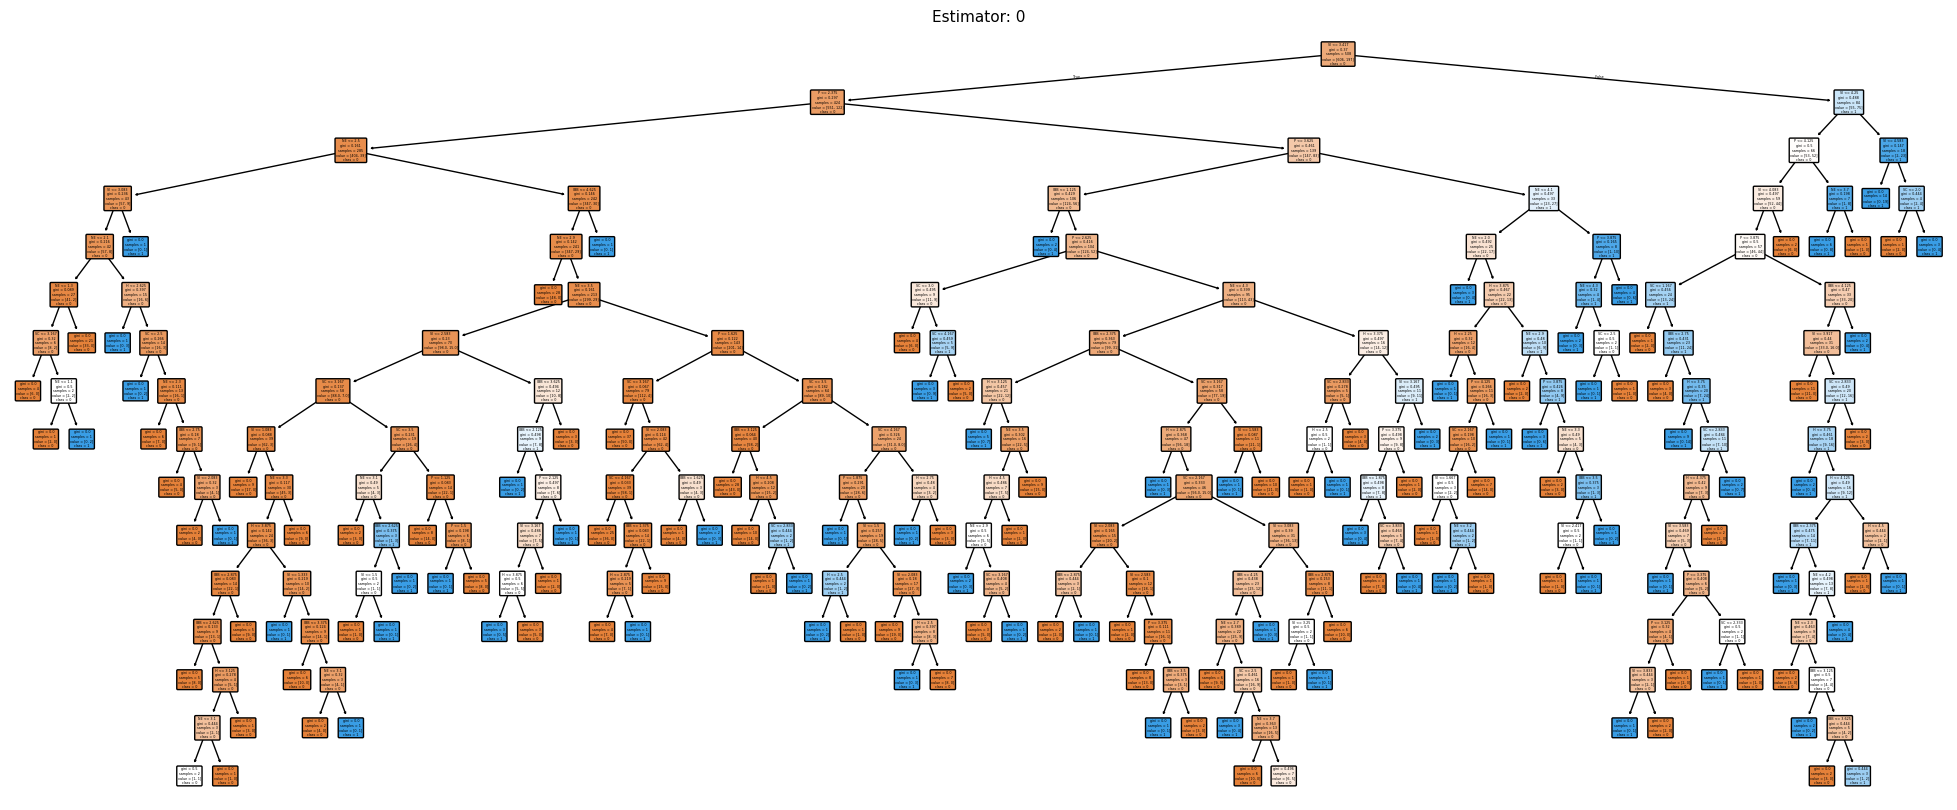

<p><span style="font-size: 1.2em;"><b>Figure 0</b>: Visualization of the first Decision Tree in Random Forest model</span></p>

In [8]:
def random_forest_fig():
    plt.figure(figsize = (25,10))
    tree.plot_tree(trained_rf.estimators_[0], feature_names=feature, class_names=target, filled=True, rounded=True)
    plt.title('Estimator: ' + str(0), fontsize = 11)     
    plt.show()

    display_title("Visualization of the first Decision Tree in Random Forest model", pref='Figure', num=0)

random_forest_fig()

Since the Decision Tree has many depths that is hard to read, we will extract the information and find the most important features that the model uses for splitting decision

In [9]:
def random_forest_results():
    display_title("Relevent scores for Random Forest model", pref='Result', num=0)

    acc_rf = cross_val_score(rf_model, X, y, cv = kf, scoring = 'accuracy')
    pre_rf = cross_val_score(rf_model, X, y, cv = kf, scoring='precision')
    rec_rf = cross_val_score(rf_model, X, y, cv = kf, scoring='recall')

    max_acc_rf = max(acc_rf)
    max_pre_rf = max(pre_rf)
    max_rec_rf = max(rec_rf)

    print(f"The highest accuracy score: {max_acc_rf:.2f}")
    print(f"The highest precision score: {max_pre_rf:.2f}")
    print(f"The highest recall score: {max_rec_rf:.2f}")
    print(f"The average accuracy of the model: {np.mean(acc_rf):.2f}")
    print(f"The average precision of the model: {np.mean(pre_rf):.2f}")
    print(f"The average recall of the model: {np.mean(pre_rf):.2f}")
    
    display_title("Features' importance and the Top 3 most important features", pref='Table', num=0)
    # extracting the importance score from the model
    importances = trained_rf.feature_importances_
    feature_importance_df = pd.DataFrame({'Feature': feature, 'Importance': importances})

    # ranking the importance score
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending = False)
    display(feature_importance_df)

    # top 3 importance features
    top_3 = list(feature_importance_df['Feature'][:3].values)
    print(f"Top 3 most importance features: {top_3}")
    
random_forest_results()

<br><br><p><span style="font-size: 1.2em;"><b>Result 0</b>: Relevent scores for Random Forest model</span></p>

The highest accuracy score: 0.85
The highest precision score: 0.80
The highest recall score: 0.65
The average accuracy of the model: 0.79
The average precision of the model: 0.59
The average recall of the model: 0.59


<br><br><p><span style="font-size: 1.2em;"><b>Table 0</b>: Features' importance and the Top 3 most important features</span></p>

,Feature,Importance
0,P,0.268764
1,SI,0.181253
4,NE,0.160502
5,IBB,0.150353
2,SC,0.120346
3,H,0.118782


Top 3 most importance features: ['P', 'SI', 'NE']


We will try to predict with a Logistic Regression model this time!

In [10]:
LG_model = LogisticRegression(random_state=42, class_weight='balanced')

LG_acc = cross_val_score(LG_model, X, y, cv = kf, scoring='accuracy')
LG_pre = cross_val_score(LG_model, X, y, cv = kf, scoring='precision')
LG_rec = cross_val_score(LG_model, X, y, cv = kf, scoring='recall')

trained_LG = LG_model.fit(X, y)

max_LG_acc = max(LG_acc)
max_LG_pre = max(LG_pre)
max_LG_rec = max(LG_rec)

print(f"The highest accuracy score: {max_LG_acc:.2f}") 
print(f"The highest precision score: {max_LG_pre:.2f}")
print(f"The highest recall score: {max_LG_rec:.2f}")
print(f"The average accuracy for the model: {np.mean(LG_acc):.2f}")
print(f"The average precision of the model: {np.mean(LG_pre):.2f}")
print(f"The average recall of the model: {np.mean(LG_rec):.2f}")

The highest accuracy score: 0.86
The highest precision score: 0.68
The highest recall score: 0.87
The average accuracy for the model: 0.73
The average precision of the model: 0.48
The average recall of the model: 0.73


Although the Logistic Regression has a lower precision score, the recall score is much better compared to the Random Forest model.

From the business perspective, recall score would have higher importance because it resembles closer with their customer base. Missing a false negative user respondent is much more costly for business than identify a false positive non-user. Therefore, Logistic Regression would be the more relevant model.

We will map the Logistic Regression model's confusion matrix and graph for data visualization.

We can also check for feature coefficient to see which feature has higher impact on the model's decision.

<br><br><p><span style="font-size: 1.2em;"><b>Result 1</b>: Relevent scores for Logistic Regression model</span></p>

The highest accuracy score: 0.86
The highest precision score: 0.68
The highest recall score: 0.87
The average accuracy for the model: 0.73
The average precision of the model: 0.48
The average recall of the model: 0.73


<p><span style="font-size: 1.2em;"><b>Figure 1</b>: Confusion matrix of Logistic Regression model</span></p>

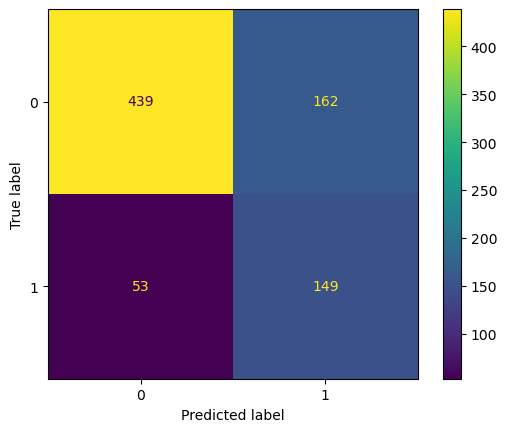

<br><br><p><span style="font-size: 1.2em;"><b>Table 1</b>: Feature Importance using Coefficient</span></p>

,Feature,Coefficient,Absolute Coefficient
0,P,0.887261,0.887261
1,SI,0.389794,0.389794
3,H,-0.322211,0.322211
2,SC,0.178874,0.178874
5,IBB,0.087921,0.087921
4,NE,0.004942,0.004942


In [11]:
def LG_model_results ():
    display_title("Relevent scores for Logistic Regression model", pref = 'Result', num = 1)
    print(f"The highest accuracy score: {max_LG_acc:.2f}") 
    print(f"The highest precision score: {max_LG_pre:.2f}")
    print(f"The highest recall score: {max_LG_rec:.2f}")
    print(f"The average accuracy for the model: {np.mean(LG_acc):.2f}")
    print(f"The average precision of the model: {np.mean(LG_pre):.2f}")
    print(f"The average recall of the model: {np.mean(LG_rec):.2f}")
    
    display_title("Confusion matrix of Logistic Regression model", pref='Figure', num=1)
    y_predict = cross_val_predict(LG_model, X, y, cv = kf)

    cm = confusion_matrix(y, y_predict)

    model_cm_visual = ConfusionMatrixDisplay(cm)
    model_cm_visual.plot()
    plt.show()

    coefficients = LG_model.coef_[0]
    abs_coefficients = abs(LG_model.coef_[0])
    feature_coefficient = pd.DataFrame({'Feature': X.columns, 'Coefficient': coefficients, 'Absolute Coefficient': abs_coefficients})

    display_title("Feature Importance using Coefficient", pref='Table', num=1)
    display(feature_coefficient.sort_values(by='Absolute Coefficient', ascending = False))

    

LG_model_results()

Comparing the feature importance result of 2 models, while Promotion and Social Influence are the most influential features in both models, the Logistic Regression model has Happiness as the third most instead of Normative Evaluation in Random Forest model.

Given the higher recall score of the Logistic Regression model, we can infer that the Happiness provides stronger signal to differentiate users and non-users rather than relying more heavily on Normative Evaluation and other features not in top 3 for this model.

---

While User status determines the customer base of the BNPL service, the Impulsive Buying Behavior (IBB) tells how much a customer is willing to spend their money on the service. Therefore, we will also plot a predict regression for the IBB score.

We will first try with a KNN Regression model

In [12]:
X_reg = df[['P', 'SI', 'SC', 'H', 'NE']]
feature = df[['P', 'SI', 'SC', 'H', 'NE']].columns.tolist()
print(feature)

y_reg = df['IBB']
target = sorted(df['IBB'].unique().astype(str))
print(target)

['P', 'SI', 'SC', 'H', 'NE']
['1.0', '1.25', '1.5', '1.75', '2.0', '2.25', '2.5', '2.75', '3.0', '3.25', '3.5', '3.75', '4.0', '4.25', '4.5', '4.75', '5.0']


In [13]:
k_mod = KNeighborsRegressor(n_neighbors=58, weights='distance')         # during the process of tuning, I found out that by setting the neighbors to 58 returns the best result
k_rsme = cross_val_score(k_mod, X_reg, y_reg, cv = kf, scoring = 'neg_root_mean_squared_error')
k_r2 = cross_val_score(k_mod, X_reg, y_reg, cv = kf, scoring = 'r2')

trained_kneighbor = k_mod.fit(X_reg, y_reg)

print(f"Root Mean Squared Error (RMSE) of KNN Regressor model: {np.mean(-k_rsme):.4f}")
print(f"Coefficient of Determination (R²) of KNN Regressor model: {np.mean(k_r2):.4f}")

Root Mean Squared Error (RMSE) of KNN Regressor model: 0.7373
Coefficient of Determination (R²) of KNN Regressor model: 0.2837


A RMSE score of 0.7373 is a reasonable score compared to the scale of the actual data (1-5). For example, if the predicted score for IBB is 4, the range of the actual data should be 4 ± 0.7373. However, the R² score being ~0.28 means the model has weak predictive power in explaining the variance of the target data.

Let's try to predict with the Support Vector Regression model this time!

In [14]:
svr_mod_rbf = SVR(kernel='rbf')

svr_rsme = cross_val_score(svr_mod_rbf, X_reg, y_reg, cv = kf, scoring = 'neg_root_mean_squared_error')
svr_r2 = cross_val_score(svr_mod_rbf, X_reg, y_reg, cv = kf, scoring = 'r2')

trained_SVR = svr_mod_rbf.fit(X_reg, y_reg)

print(f"Root Mean Squared Error (RMSE) of SVR model with RBF kernel: {np.mean(-svr_rsme):.4f}")
print(f"Coefficient of Determination (R²) of SVR model with RBF kernel: {np.mean(svr_r2):.4f}")

Root Mean Squared Error (RMSE) of SVR model with RBF kernel: 0.7550
Coefficient of Determination (R²) of SVR model with RBF kernel: 0.2465


Using K-Fold cross-validation, we can see that the KNN Regressor model performed better than the Support Vector Regression model.

We will use the trained KNN Regressor model for visualization.

We can check for the KNN Regressor's prediction by comparing predicted value and the actual value.

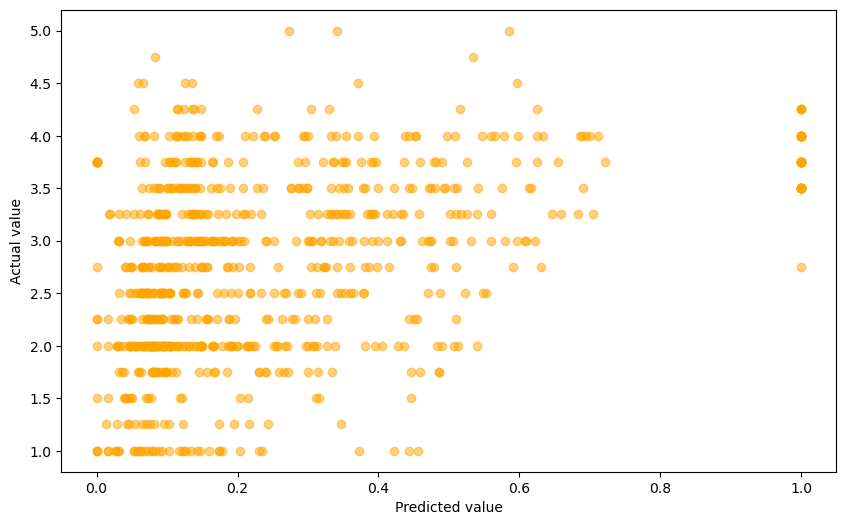

In [15]:
y_reg_predict = cross_val_predict(k_mod, X, y, cv = kf)

plt.figure(figsize=(10,6))
plt.scatter(y_reg_predict, y_reg, alpha=0.5, color='orange')
plt.xlabel('Predicted value')
plt.ylabel('Actual value')
plt.show()

With the information on the KNN Regressor model, let's compile them for reporting!

<br><br><p><span style="font-size: 1.2em;"><b>Result 2</b>: Relevent scores for KNN Regressor model in predicting the IBB score</span></p>

Root Mean Squared Error (RMSE) of KNN Regressor model: 0.7373
Coefficient of Determination (R²) of KNN Regressor model: 0.2837


<p><span style="font-size: 1.2em;"><b>Figure 2</b>: Predicted IBB value and Actual IBB value</span></p>

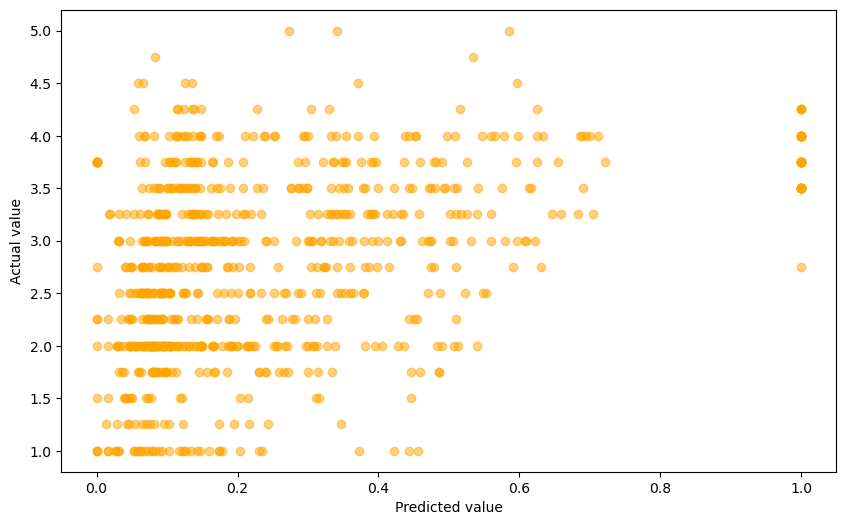

In [16]:
def KNN_reg_results():
    display_title("Relevent scores for KNN Regressor model in predicting the IBB score", pref = 'Result', num = 2)
    print(f"Root Mean Squared Error (RMSE) of KNN Regressor model: {np.mean(-k_rsme):.4f}")
    print(f"Coefficient of Determination (R²) of KNN Regressor model: {np.mean(k_r2):.4f}")

    display_title("Predicted IBB value and Actual IBB value", pref='Figure', num=2)
    plt.figure(figsize=(10,6))
    plt.scatter(y_reg_predict, y_reg, alpha=0.5, color='orange')
    plt.xlabel('Predicted value')
    plt.ylabel('Actual value')
    plt.show()

KNN_reg_results()